In [1]:
import pandas as pd
gene_to_idx_plasma = pd.read_csv('PR80_30/gene_to_idx_400_plasma.csv')
gene_to_idx_tissue = pd.read_csv('PR80_30/gene_to_idx_400_tissue.csv')

In [36]:
import torch
tissue_results = torch.load('training_plots/orth_recon_task/explainer_fold_results_tissue.pt', weights_only=False)
plasma_results = torch.load('training_plots/orth_recon_task/explainer_fold_results_plasma.pt', weights_only=False)

In [37]:
plasma_results

{0: {(np.str_('Sample 15'),): Explanation(node_mask=[1340, 1], prediction=[1], target=[1], x=[1340, 1], edge_index=[2, 56820], batch=[1340]),
  (np.str_('Sample 17'),): Explanation(node_mask=[1340, 1], prediction=[1], target=[1], x=[1340, 1], edge_index=[2, 56820], batch=[1340]),
  (np.str_('Sample 28'),): Explanation(node_mask=[1340, 1], prediction=[1], target=[1], x=[1340, 1], edge_index=[2, 56820], batch=[1340]),
  (np.str_('Sample 29'),): Explanation(node_mask=[1340, 1], prediction=[1], target=[1], x=[1340, 1], edge_index=[2, 56820], batch=[1340]),
  (np.str_('Sample 34'),): Explanation(node_mask=[1340, 1], prediction=[1], target=[1], x=[1340, 1], edge_index=[2, 56820], batch=[1340]),
  (np.str_('Sample 38'),): Explanation(node_mask=[1340, 1], prediction=[1], target=[1], x=[1340, 1], edge_index=[2, 56820], batch=[1340]),
  (np.str_('Sample 61'),): Explanation(node_mask=[1340, 1], prediction=[1], target=[1], x=[1340, 1], edge_index=[2, 56820], batch=[1340]),
  (np.str_('Sample 76'),

In [38]:
gene_to_idx_tissue

,Unnamed: 0,Gene,idx
0,0,NHP2,0
1,1,IDH3B,1
2,2,MRPL14,2
3,3,ARHGAP35,3
4,4,SPTAN1,4
...,...,...,...
6392,6392,CDC42BPA,6392
6393,6393,KCTD10,6393
6394,6394,INPP1,6394
6395,6395,BORCS7,6395


In [39]:
import numpy as np

idx_to_gene = dict(
    zip(gene_to_idx_tissue["idx"], gene_to_idx_tissue["Gene"])
)

# Get one explanation
sample_key = list(tissue_results[0].keys())[0]
explanation = tissue_results[0][sample_key]

assert len(gene_to_idx_tissue) == explanation.node_mask.shape[0]
assert list(gene_to_idx_tissue["idx"]) == list(range(6397))

# Node importance
node_importance = explanation.node_mask.detach().cpu().numpy().squeeze()

# Create dataframe
tissue_explanation = pd.DataFrame({
    "idx": np.arange(len(node_importance)),
    "gene": [idx_to_gene[i] for i in range(len(node_importance))],
    "importance": node_importance
})

# Highest importance first
tissue_explanation = tissue_explanation.sort_values(
    "importance",
    ascending=False
)

tissue_explanation.head(20)

,idx,gene,importance
2278,2278,CD34,0.908238
2096,2096,H1-4,0.894269
6112,6112,HSPB1,0.892044
5502,5502,CFHR3,0.889973
2546,2546,MSRA,0.889218
4408,4408,RECK,0.888977
5851,5851,CFHR1,0.887874
3516,3516,IGHV3-72,0.887780
6377,6377,CAPRIN1,0.887490
4823,4823,SRI,0.887441


In [40]:
all_explanations = []

for fold, fold_results in tissue_results.items():

    for sample_key, explanation in fold_results.items():

        # sample_key is something like ('Sample 15',)
        sample = sample_key[0]

        importance = (
            explanation.node_mask
            .detach()
            .cpu()
            .numpy()
            .squeeze()
        )

        for idx, score in enumerate(importance):

            all_explanations.append({
                "fold": fold,
                "sample": sample,
                "idx": idx,
                "gene": idx_to_gene[idx],
                "importance": score
            })

tissue_explanations_df = pd.DataFrame(all_explanations)

In [41]:
tissue_explanations_df

,fold,sample,idx,gene,importance
0,0,Sample 15,0,NHP2,0.000000
1,0,Sample 15,1,IDH3B,0.000000
2,0,Sample 15,2,MRPL14,0.000000
3,0,Sample 15,3,ARHGAP35,0.000000
4,0,Sample 15,4,SPTAN1,0.125639
...,...,...,...,...,...
204699,2,Sample 83,6392,CDC42BPA,0.000000
204700,2,Sample 83,6393,KCTD10,0.000000
204701,2,Sample 83,6394,INPP1,0.000000
204702,2,Sample 83,6395,BORCS7,0.000000


In [42]:
all_explanations_plasma = []
idx_to_gene_plasma = dict(
    zip(gene_to_idx_plasma["idx"], gene_to_idx_plasma["Gene"])
)
for fold, fold_results in plasma_results.items():

    for sample_key, explanation in fold_results.items():

        # sample_key is something like ('Sample 15',)
        sample = sample_key[0]
        print(sample)

        importance = (
            explanation.node_mask
            .detach()
            .cpu()
            .numpy()
            .squeeze()
        )
        print(importance)

        for idx, score in enumerate(importance):

            all_explanations_plasma.append({
                "fold": fold,
                "sample": sample,
                "idx": idx,
                "gene": idx_to_gene_plasma[idx],
                "importance": score
            })

plasma_explanations_df = pd.DataFrame(all_explanations_plasma)

Sample 15
[0.14241847 0.13167039 0.2481911  ... 0.13402843 0.10975727 0.13888638]
Sample 17
[0.16206719 0.12556617 0.14235781 ... 0.15946111 0.11626542 0.14970358]
Sample 28
[0.15169856 0.1440678  0.1286724  ... 0.14699234 0.13448896 0.14271215]
Sample 29
[0.6881464  0.5156439  0.70038944 ... 0.82606554 0.8023416  0.6294388 ]
Sample 34
[0.1342615  0.16141511 0.13826287 ... 0.14454499 0.14371498 0.14169297]
Sample 38
[0.15601692 0.1408117  0.16132595 ... 0.19059798 0.1180047  0.14506067]
Sample 61
[0.16590597 0.145137   0.13688055 ... 0.11149551 0.13888125 0.1329867 ]
Sample 76
[0.74330765 0.69970375 0.72553676 ... 0.8037022  0.17035446 0.19639592]
Sample 78
[0.7455087  0.7048262  0.7051412  ... 0.74531275 0.10091922 0.69020957]
Sample 85
[0.1630904  0.11917034 0.84905344 ... 0.85695386 0.14758018 0.13053817]
Sample 88
[0.11912362 0.7696807  0.76365507 ... 0.8186926  0.10910518 0.66918874]
Sample 16
[0.13901524 0.12748367 0.1352756  ... 0.14244188 0.14237788 0.1498662 ]
Sample 18
[0.737

In [43]:
print(plasma_explanations_df.head())

   fold     sample  idx    gene  importance
0     0  Sample 15    0    ARF4    0.142418
1     0  Sample 15    1   COX5B    0.131670
2     0  Sample 15    2   AP2S1    0.248191
3     0  Sample 15    3  SPTAN1    0.159736
4     0  Sample 15    4   AP4S1    0.141643


In [44]:
tissue_explanations_df = (tissue_explanations_df.sort_values(['sample','importance'],ascending=[True,False]))
plasma_explanations_df = (plasma_explanations_df.sort_values(['sample','importance'],ascending=[True,False]))


In [45]:
tissue_explanations_df.head(20)

,fold,sample,idx,gene,importance
143613,2,Sample 1,2879,KRT78,0.863022
141578,2,Sample 1,844,CSTA,0.852806
146101,2,Sample 1,5367,GM2A,0.845209
145012,2,Sample 1,4278,KRT6A,0.843652
145360,2,Sample 1,4626,CTSF,0.839835
146752,2,Sample 1,6018,MFAP2,0.837124
146425,2,Sample 1,5691,SERPINB3,0.834572
146909,2,Sample 1,6175,KRT16,0.829708
146973,2,Sample 1,6239,KRT17,0.829303
142244,2,Sample 1,1510,S100A7,0.828211


In [46]:
top_n = 20

top_genes = (
    tissue_explanations_df.groupby('sample').head(top_n)
)

gene_frequency = (
    top_genes["gene"]
    .value_counts()
    .rename("n_samples")
    .to_frame()
)

gene_frequency["fraction_samples"] = (
    gene_frequency["n_samples"] /
    tissue_explanations_df["sample"].nunique()
)

gene_frequency.head(30)

,n_samples,fraction_samples
gene,,
GAPDH,6,0.18750
ACTB,5,0.15625
HSPA9,5,0.15625
RHOA,4,0.12500
CASP3,4,0.12500
CDC42,4,0.12500
GRB2,4,0.12500
NID2,4,0.12500
LMNA,4,0.12500


In [47]:
top_n = 20

top_genes = (
    plasma_explanations_df.groupby('sample').head(top_n)
)

gene_frequency = (
    top_genes["gene"]
    .value_counts()
    .rename("n_samples")
    .to_frame()
)

gene_frequency["fraction_samples"] = (
    gene_frequency["n_samples"] /
    plasma_explanations_df["sample"].nunique()
)

gene_frequency.head(30)

,n_samples,fraction_samples
gene,,
CALR,7,0.21875
ACTB,5,0.15625
PSMD14,4,0.12500
GAPDH,4,0.12500
GRB2,4,0.12500
HSP90AA1,4,0.12500
TPI1,4,0.12500
CDC42,4,0.12500
SRI,4,0.12500


In [48]:
hallmark_dir = "/scratch/bmep/plalfken/Venkat/pathway_datasets/h.all.v2026.1.Hs.symbols.gmt"
reactome_dir = "/scratch/bmep/plalfken/Venkat/pathway_datasets/c2.cp.reactome.v2026.1.Hs.symbols.gmt"

In [51]:
tissue_ssgsea = tissue_explanations_df.pivot(
    index="gene",
    columns="sample",
    values="importance"
)
plasma_ssgsea = plasma_explanations_df.pivot(
    index="gene",
    columns="sample",
    values="importance"
)
tissue_ssgsea

sample,Sample 1,Sample 15,Sample 16,Sample 17,Sample 18,Sample 22,Sample 23,Sample 25,Sample 28,Sample 29,...,Sample 65,Sample 7,Sample 70,Sample 76,Sample 78,Sample 79,Sample 83,Sample 85,Sample 87,Sample 88
gene,,,,,,,,,,,,,,,,,,,,,
A1BG,0.139417,0.162523,0.164928,0.147435,0.257870,0.161483,0.130609,0.129363,0.150504,0.142089,...,0.095464,0.149975,0.162829,0.120989,0.472858,0.139487,0.136953,0.114277,0.778426,0.814656
A2M,0.159520,0.132740,0.154096,0.166109,0.388699,0.753008,0.129799,0.152805,0.153392,0.876524,...,0.106124,0.133068,0.143937,0.868014,0.107808,0.127859,0.146683,0.857060,0.785362,0.861997
AAAS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AACS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AAGAB,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZSWIM8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ZW10,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ZYG11B,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [52]:
import gseapy as gp

tissue_pathways = gp.ssgsea(
    data=tissue_ssgsea,
    gene_sets=reactome_dir,
    outdir=None,
    sample_norm_method="rank"
)

plasma_pathways = gp.ssgsea(
    data=plasma_ssgsea,
    gene_sets=reactome_dir,
    outdir=None,
    sample_norm_method="rank"
)

In [53]:
tissue_scores = tissue_pathways.res2d.pivot(
    index="Name",
    columns="Term",
    values="NES"
)
plasma_scores = plasma_pathways.res2d.pivot(
    index="Name",
    columns="Term",
    values="NES"
)

In [54]:
print(plasma_scores.head())

Term       REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT  \
Name                                                         
Sample 1                                          0.309065   
Sample 15                                         0.087512   
Sample 16                                         0.191684   
Sample 17                                         0.452898   
Sample 18                                         0.232258   

Term       REACTOME_ABC_TRANSPORTER_DISORDERS  \
Name                                            
Sample 1                             0.313271   
Sample 15                            0.073116   
Sample 16                            0.206431   
Sample 17                            0.452424   
Sample 18                            0.216690   

Term       REACTOME_ACTIVATION_OF_APC_C_AND_APC_C_CDC20_MEDIATED_DEGRADATION_OF_MITOTIC_PROTEINS  \
Name                                                                                               
Sample 1             

In [55]:
print(plasma_scores.shape)

(32, 306)


In [57]:
plasma_scores.columns

Index(['REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT',
       'REACTOME_ABC_TRANSPORTER_DISORDERS',
       'REACTOME_ACTIVATION_OF_APC_C_AND_APC_C_CDC20_MEDIATED_DEGRADATION_OF_MITOTIC_PROTEINS',
       'REACTOME_ACTIVATION_OF_NF_KAPPAB_IN_B_CELLS',
       'REACTOME_ADAPTIVE_IMMUNE_SYSTEM',
       'REACTOME_ADHERENS_JUNCTIONS_INTERACTIONS',
       'REACTOME_AEROBIC_RESPIRATION_AND_RESPIRATORY_ELECTRON_TRANSPORT',
       'REACTOME_AMPK_INDUCED_ERAD_AND_LYSOSOME_MEDIATED_DEGRADATION_OF_PD_L1_CD274',
       'REACTOME_AMYLOID_FIBER_FORMATION',
       'REACTOME_ANCHORING_OF_THE_BASAL_BODY_TO_THE_PLASMA_MEMBRANE',
       ...
       'REACTOME_TRANS_GOLGI_NETWORK_VESICLE_BUDDING',
       'REACTOME_UBIQUITIN_DEPENDENT_DEGRADATION_OF_CYCLIN_D',
       'REACTOME_UBIQUITIN_MEDIATED_DEGRADATION_OF_PHOSPHORYLATED_CDC25A',
       'REACTOME_UB_SPECIFIC_PROCESSING_PROTEASES', 'REACTOME_UCH_PROTEINASES',
       'REACTOME_UNFOLDED_PROTEIN_RESPONSE_UPR',
       'REACTOME_VESICLE_MEDIATED_TRANSPORT',
  

In [67]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# all pathways
X = tissue_scores.copy()

# remove pathways with missing values
X = X.dropna(axis=1)

# standardize each pathway across patients
X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    index=X.index,
    columns=["PC1", "PC2"]
)

print("Explained variance:")
print("PC1:", pca.explained_variance_ratio_[0])
print("PC2:", pca.explained_variance_ratio_[1])
print("Total:", pca.explained_variance_ratio_[:2].sum())

Explained variance:
PC1: 0.25342644308268825
PC2: 0.14699032089017997
Total: 0.4004167639728682


In [68]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=["PC1", "PC2"]
)
pc1_loading = (
    loadings["PC1"]
    .sort_values(key=abs, ascending=False)
)
pc2_loading = (
    loadings["PC2"]
    .sort_values(key=abs, ascending=False)
)

print(pc2_loading.head(20))

Term
REACTOME_ANTI_INFLAMMATORY_RESPONSE_FAVOURING_LEISHMANIA_PARASITE_INFECTION    0.070149
REACTOME_G_PROTEIN_BETA_GAMMA_SIGNALLING                                       0.068760
REACTOME_ANTIGEN_PROCESSING_UB_ATP_INDEPENDENT_PROTEASOMAL_DEGRADATION        -0.067253
REACTOME_SIGNAL_AMPLIFICATION                                                  0.067073
REACTOME_GLUCOSE_METABOLISM                                                    0.067026
REACTOME_INTERLEUKIN_3_INTERLEUKIN_5_AND_GM_CSF_SIGNALING                      0.066987
REACTOME_METABOLISM_OF_NUCLEOTIDES                                             0.066437
REACTOME_G_ALPHA_S_SIGNALLING_EVENTS                                           0.066129
REACTOME_AZATHIOPRINE_ADME                                                     0.065992
REACTOME_GABA_RECEPTOR_ACTIVATION                                              0.065916
REACTOME_GABA_B_RECEPTOR_ACTIVATION                                            0.065913
REACTOME_EXTRA_NUCLEAR_ESTR

In [69]:
print("PC1 positive:")
print(loadings["PC1"].sort_values(ascending=False).head(10))

print("\nPC1 negative:")
print(loadings["PC1"].sort_values(ascending=True).head(10))

print("\nPC2 positive:")
print(loadings["PC2"].sort_values(ascending=False).head(10))

print("\nPC2 negative:")
print(loadings["PC2"].sort_values(ascending=True).head(10))

PC1 positive:
Term
REACTOME_ADAPTIVE_IMMUNE_SYSTEM                                                              0.069643
REACTOME_CELL_CYCLE                                                                          0.068905
REACTOME_CELL_CYCLE_MITOTIC                                                                  0.068367
REACTOME_CELL_CYCLE_CHECKPOINTS                                                              0.066892
REACTOME_SIGNALING_BY_WNT                                                                    0.066670
REACTOME_MITOTIC_G2_G2_M_PHASES                                                              0.066574
REACTOME_NERVOUS_SYSTEM_DEVELOPMENT                                                          0.066509
REACTOME_RNA_POLYMERASE_II_TRANSCRIPTION                                                     0.066064
REACTOME_DISEASES_OF_SIGNAL_TRANSDUCTION_BY_GROWTH_FACTOR_RECEPTORS_AND_SECOND_MESSENGERS    0.065758
REACTOME_REGULATION_OF_T_CELL_ACTIVATION_BY_CD28_FAMILY        

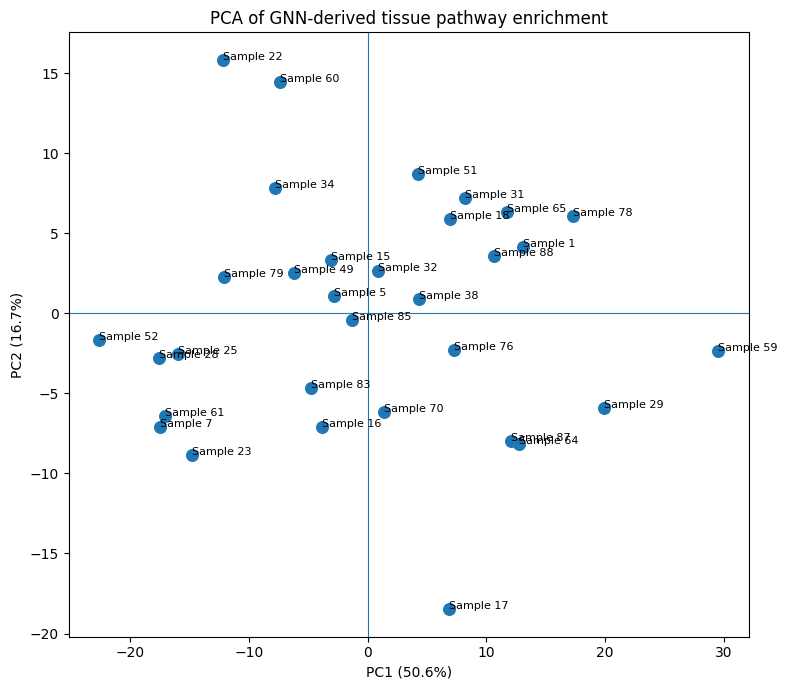

In [61]:
plt.figure(figsize=(8, 7))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    s=70
)

for patient, row in pca_df.iterrows():
    plt.text(
        row["PC1"],
        row["PC2"],
        str(patient),
        fontsize=8
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA of GNN-derived tissue pathway enrichment")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.tight_layout()
plt.show()

In [70]:
pathway_variability = (
    tissue_scores
    .std()
    .sort_values(ascending=False)
)

print(pathway_variability.head(30))

Term
REACTOME_ANTIGEN_PROCESSING_UB_ATP_INDEPENDENT_PROTEASOMAL_DEGRADATION               0.031806
REACTOME_INITIAL_TRIGGERING_OF_COMPLEMENT                                            0.030301
REACTOME_PLASMA_LIPOPROTEIN_ASSEMBLY                                                 0.029611
REACTOME_GRB2_SOS_PROVIDES_LINKAGE_TO_MAPK_SIGNALING_FOR_INTEGRINS                   0.029189
REACTOME_P130CAS_LINKAGE_TO_MAPK_SIGNALING_FOR_INTEGRINS                             0.028541
REACTOME_COMMON_PATHWAY_OF_FIBRIN_CLOT_FORMATION                                     0.028493
REACTOME_COMPLEMENT_CASCADE                                                          0.027857
REACTOME_PLASMA_LIPOPROTEIN_REMODELING                                               0.026700
REACTOME_CELL_EXTRACELLULAR_MATRIX_INTERACTIONS                                      0.026643
REACTOME_INTRINSIC_PATHWAY_OF_FIBRIN_CLOT_FORMATION                                  0.026323
REACTOME_DISEASES_OF_HEMOSTASIS                        

In [75]:
pathway_stats = pd.DataFrame({
    "mean": plasma_scores.mean(),
    "std": plasma_scores.std(),
    "min": plasma_scores.min(),
    "max": plasma_scores.max()
})

pathway_stats = pathway_stats.sort_values(
    "std",
    ascending=False
)

print(pathway_stats.sort_values(by='std',ascending=False).head(30))

                                                        mean       std  \
Term                                                                     
REACTOME_ANTIGEN_PROCESSING_UB_ATP_INDEPENDENT_...  0.153883  0.205712   
REACTOME_FORMATION_OF_THE_CORNIFIED_ENVELOPE       -0.020284  0.195483   
REACTOME_KERATINIZATION                            -0.020284  0.195483   
REACTOME_METABOLISM_OF_FAT_SOLUBLE_VITAMINS        -0.009415  0.192387   
REACTOME_PLASMA_LIPOPROTEIN_REMODELING             -0.015991  0.183749   
REACTOME_INITIAL_TRIGGERING_OF_COMPLEMENT          -0.029681  0.181615   
REACTOME_COMMON_PATHWAY_OF_FIBRIN_CLOT_FORMATION   -0.037321  0.181146   
REACTOME_VISUAL_PHOTOTRANSDUCTION                   0.003289  0.179945   
REACTOME_HEDGEHOG_LIGAND_BIOGENESIS                 0.199731  0.178047   
REACTOME_HH_MUTANTS_ABROGATE_LIGAND_SECRETION       0.195852  0.176779   
REACTOME_AMPK_INDUCED_ERAD_AND_LYSOSOME_MEDIATE...  0.195852  0.176779   
REACTOME_ASYMMETRIC_LOCALIZATION_OF_PC

In [76]:
print(pathway_stats.sort_values(by='mean',ascending=False).head(30))

                                                        mean       std  \
Term                                                                     
REACTOME_RHO_GTPASES_ACTIVATE_WASPS_AND_WAVES       0.290358  0.149489   
REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOC...  0.289764  0.149004   
REACTOME_EPHB_MEDIATED_FORWARD_SIGNALING            0.285405  0.171834   
REACTOME_PARASITE_INFECTION                         0.278843  0.151643   
REACTOME_RHOBTB_GTPASE_CYCLE                        0.275954  0.143693   
REACTOME_COOPERATION_OF_PREFOLDIN_AND_TRIC_CCT_...  0.261423  0.152480   
REACTOME_RHO_GTPASES_ACTIVATE_FORMINS               0.261382  0.166067   
REACTOME_SIGNALING_BY_ALK_IN_CANCER                 0.258456  0.133955   
REACTOME_REGULATION_OF_PLK1_ACTIVITY_AT_G2_M_TR...  0.254061  0.161695   
REACTOME_MITOCHONDRIAL_PROTEIN_DEGRADATION          0.251361  0.142175   
REACTOME_DENGUE_VIRUS_GENOME_TRANSLATION_AND_RE...  0.250759  0.135525   
REACTOME_RHO_GTPASE_EFFECTORS         

<Figure size 1600x1000 with 0 Axes>

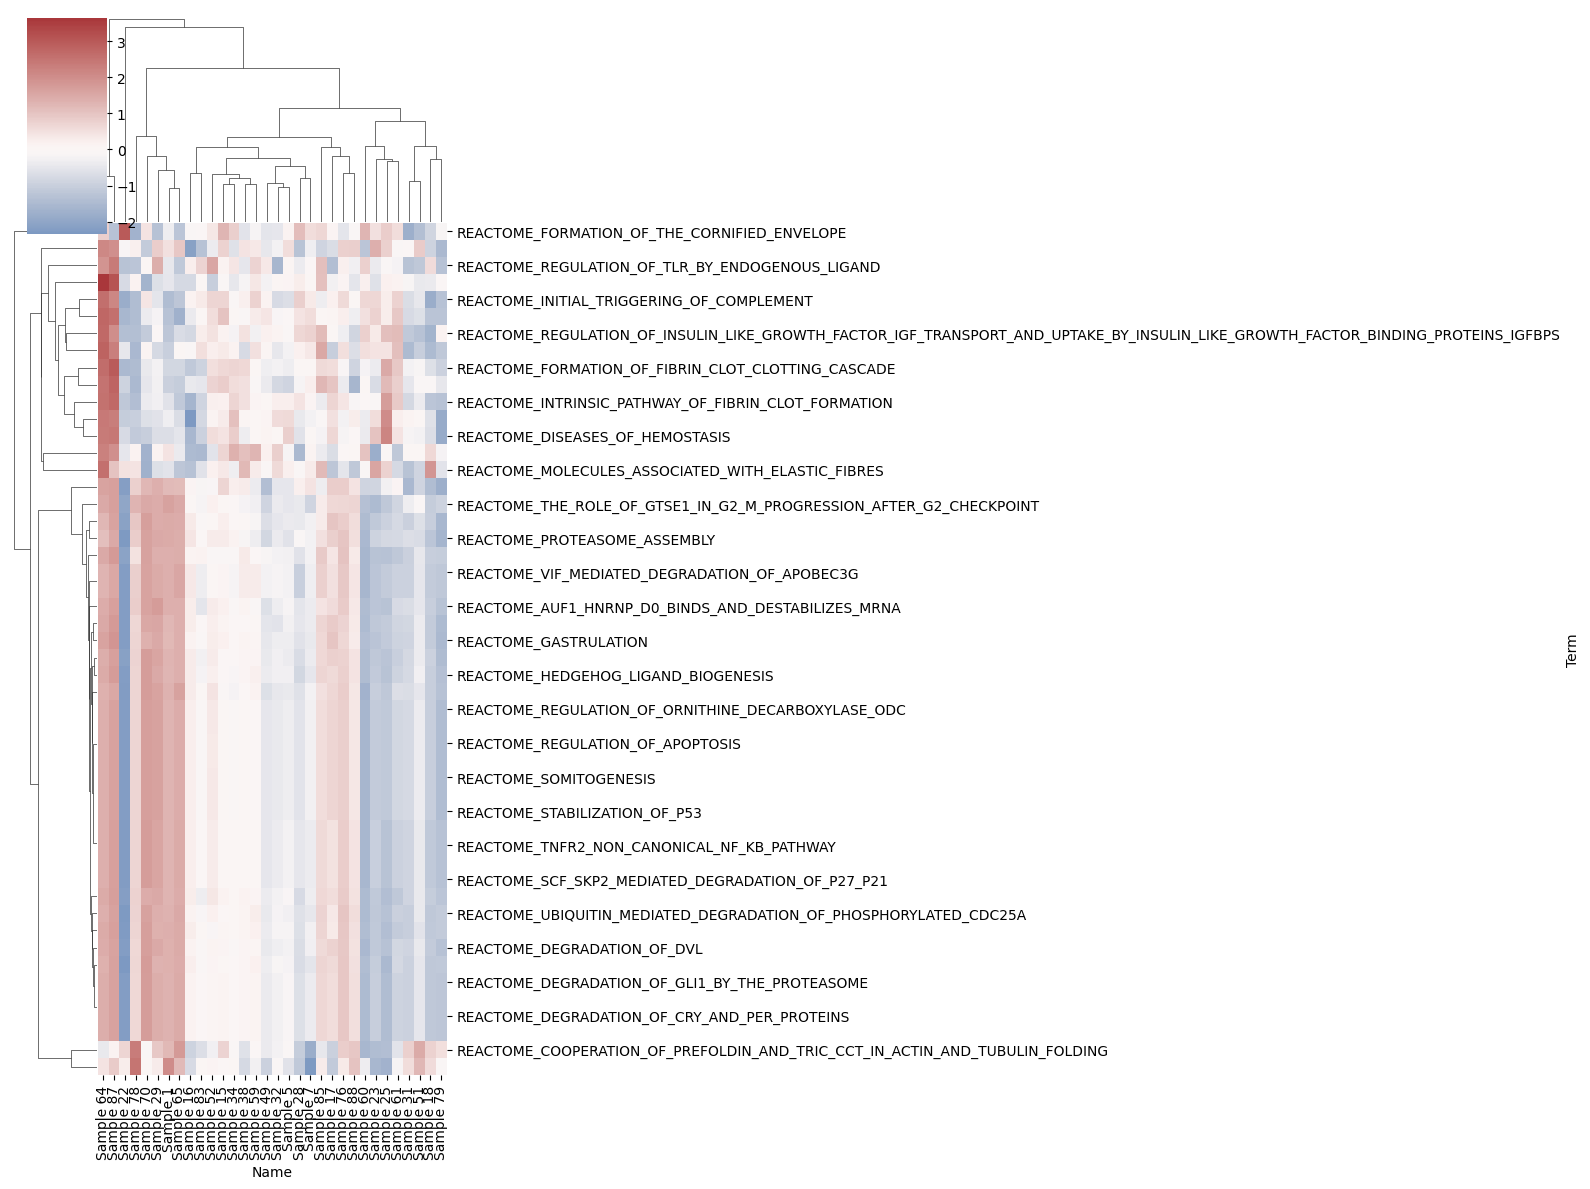

In [82]:
pathway_variability = tissue_scores.mean().sort_values(ascending=False)
top_variable = pathway_variability.head(50).index

variable_scores = tissue_scores[top_variable]
from sklearn.preprocessing import StandardScaler

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(variable_scores),
    index=variable_scores.index,
    columns=variable_scores.columns
)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))

sns.clustermap(
    X_scaled.T,
    cmap="vlag",
    center=0,
    col_cluster=True,
    row_cluster=True,
    figsize=(16, 12)
)

plt.show()